In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
pd.options.display.float_format = '{:,.2f}'.format
warnings.filterwarnings('ignore')

In [2]:
#loading dataset

In [3]:
conn=sqlite3.connect('inventory.db')

df=pd.read_sql_query("SELECT * FROM vendor_sales_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,"1,750.00",145080,"3,811,251.60","142,049.00","5,101,919.55","672,819.34","260,999.20","68,601.68","1,290,667.95",25.30,0.98,1.34
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,"1,750.00",164038,"3,804,041.22","160,247.00","4,819,073.49","561,512.38","294,438.66","144,929.24","1,015,032.27",21.06,0.98,1.27
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,"1,750.00",187407,"3,418,303.68","187,140.00","4,538,120.59","461,140.15","343,854.07","123,780.22","1,119,816.91",24.68,1.00,1.33
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,"1,750.00",201682,"3,261,197.94","200,412.00","4,475,972.86","420,050.01","368,242.80","257,032.07","1,214,774.91",27.14,0.99,1.37
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,"1,750.00",138109,"3,023,206.00","135,838.00","4,223,107.62","545,778.28","249,587.83","257,032.07","1,199,901.62",28.41,0.98,1.40


In [4]:
'''---------------------------------------------------------------------------------'''

'---------------------------------------------------------------------------------'

In [5]:
'''=================================================================================='''

'=================================================================================='

In [6]:
#summary statistics
df.describe()

,VendorNumber,Brand,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
count,"10,692.00","10,692.00","10,692.00","10,692.00","10,692.00","10,692.00","10,692.00","10,692.00","10,692.00","10,692.00","10,692.00","10,692.00","10,692.00","10,692.00","10,692.00","10,692.00"
mean,"10,650.65","18,039.23",24.39,35.64,847.36,"3,140.89","30,106.69","3,077.48","42,239.07","18,793.78","1,774.23","61,433.76","12,132.38",-inf,1.71,2.50
std,"18,753.52","12,662.19",109.27,148.25,664.31,"11,095.09","123,067.80","10,952.85","167,655.27","44,952.77","10,975.58","60,938.46","46,224.34",NaN,6.02,8.46
min,2.00,58.00,0.36,0.49,50.00,1.00,0.71,0.00,0.00,0.00,0.00,0.09,"-52,002.78",-inf,0.00,0.00
25%,"3,951.00","5,793.50",6.84,10.99,750.00,36.00,453.46,33.00,729.22,289.71,4.80,"14,069.87",52.92,13.32,0.81,1.15
50%,"7,153.00","18,761.50",10.45,15.99,750.00,262.00,"3,655.46",261.00,"5,298.04","2,857.80",46.57,"50,293.62","1,399.64",30.41,0.98,1.44
75%,"9,552.00","25,514.25",19.48,28.99,750.00,"1,975.75","20,738.24","1,929.25","28,396.91","16,059.56",418.65,"79,528.99","8,660.20",39.96,1.04,1.67
max,"201,359.00","90,631.00","5,681.81","7,499.99","20,000.00","337,660.00","3,811,251.60","334,939.00","5,101,919.55","672,819.34","368,242.80","257,032.07","1,290,667.95",99.72,274.50,352.93


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,"10,692.00","10,650.65","18,753.52",2.00,"3,951.00","7,153.00","9,552.00","201,359.00"
Brand,"10,692.00","18,039.23","12,662.19",58.00,"5,793.50","18,761.50","25,514.25","90,631.00"
PurchasePrice,"10,692.00",24.39,109.27,0.36,6.84,10.45,19.48,"5,681.81"
ActualPrice,"10,692.00",35.64,148.25,0.49,10.99,15.99,28.99,"7,499.99"
Volume,"10,692.00",847.36,664.31,50.00,750.00,750.00,750.00,"20,000.00"
TotalPurchaseQuantity,"10,692.00","3,140.89","11,095.09",1.00,36.00,262.00,"1,975.75","337,660.00"
TotalPurchaseDollars,"10,692.00","30,106.69","123,067.80",0.71,453.46,"3,655.46","20,738.24","3,811,251.60"
TotalSalesQuantity,"10,692.00","3,077.48","10,952.85",0.00,33.00,261.00,"1,929.25","334,939.00"
TotalSalesDollars,"10,692.00","42,239.07","167,655.27",0.00,729.22,"5,298.04","28,396.91","5,101,919.55"
TotalSalesPrice,"10,692.00","18,793.78","44,952.77",0.00,289.71,"2,857.80","16,059.56","672,819.34"


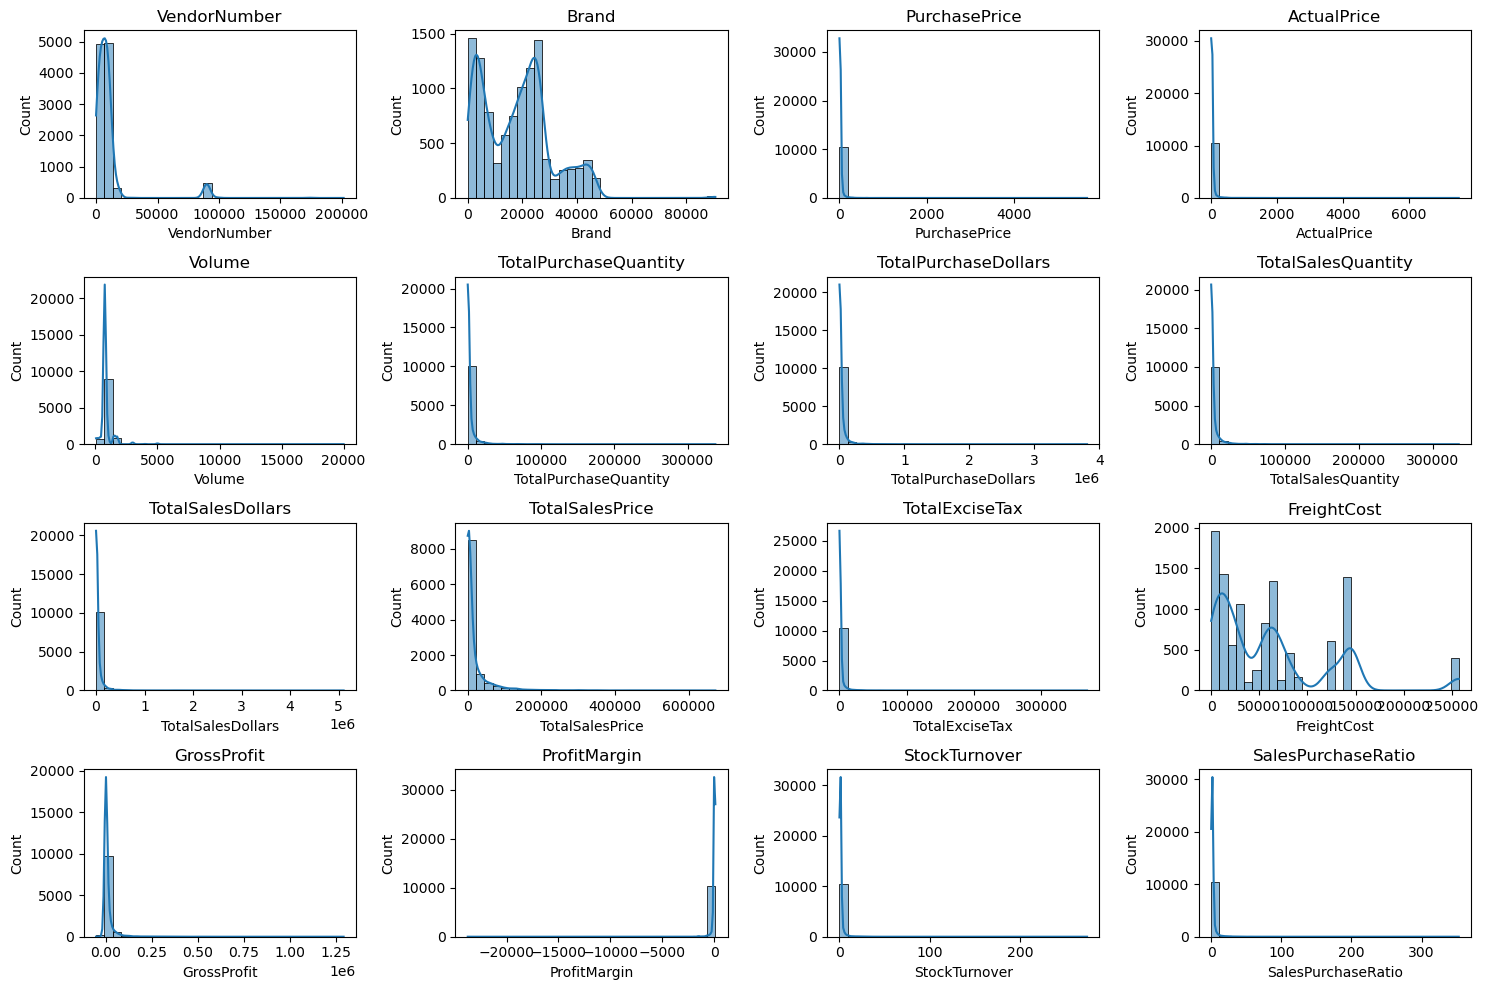

In [8]:
#Describing Plots For Numerical Columns
numerical_cols=df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)           #adjusting grid layout as needed
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

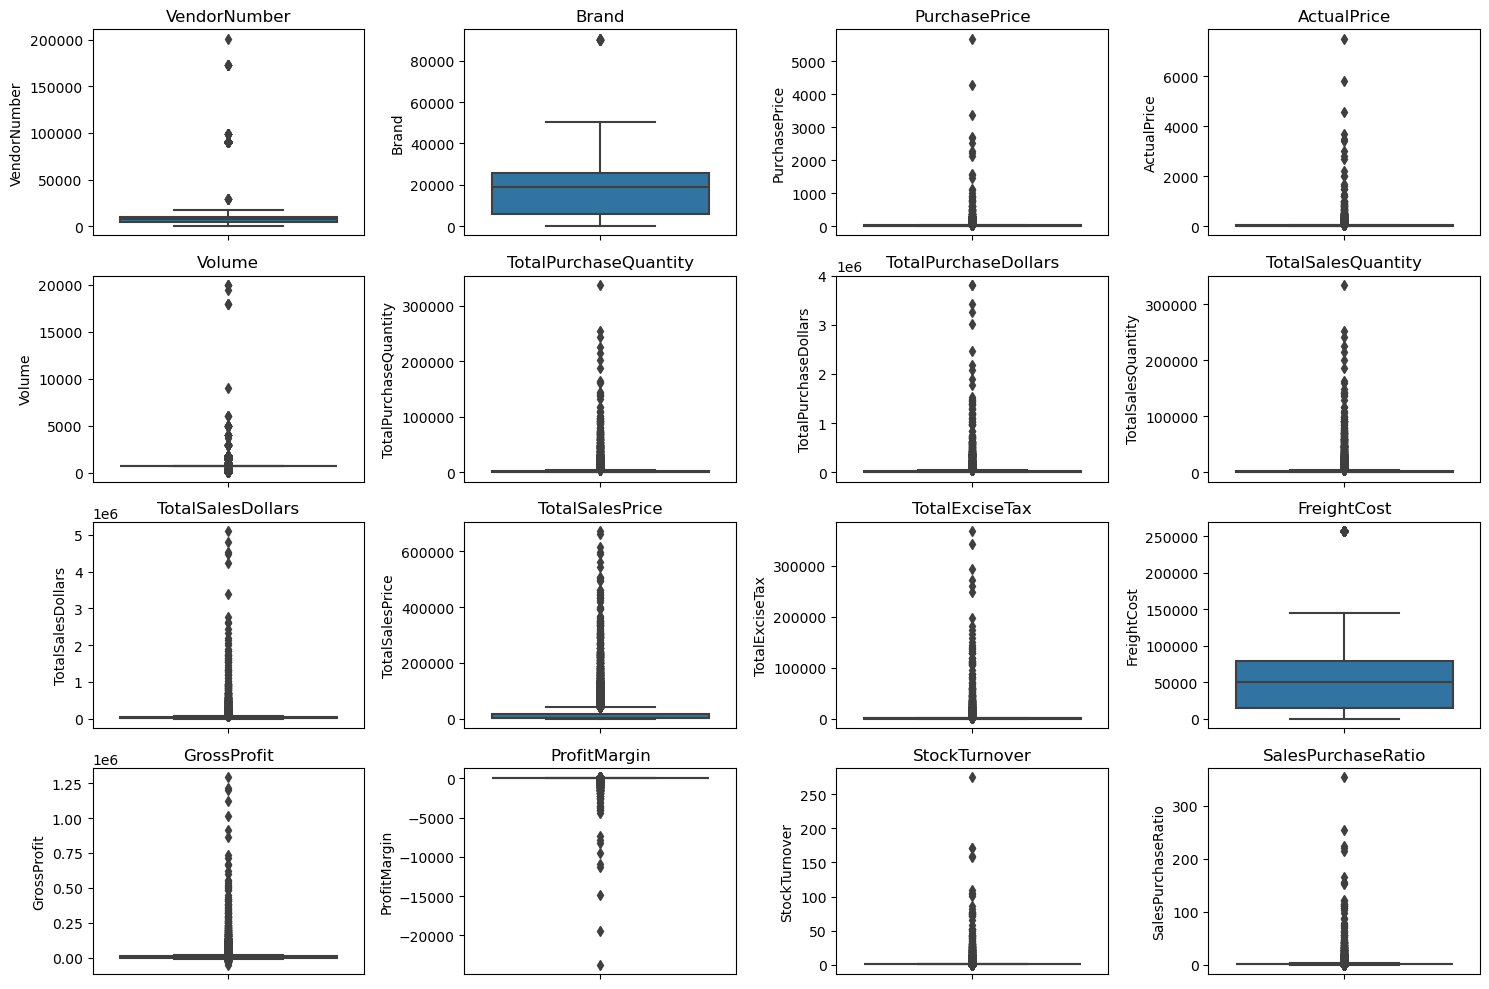

In [9]:
#Outliers detection with box plot

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)           #adjusting grid layout as needed
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [10]:
'''============================================='''

'============================================='

In [11]:
#let's filter out data by removing inconsistencies
df=pd.read_sql_query("""SELECT * 
FROM vendor_sales_summary
WHERE GrossProfit>0
AND ProfitMargin>0
AND TotalSalesQuantity>0""",conn)
df


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,"1,750.00",145080,"3,811,251.60","142,049.00","5,101,919.55","672,819.34","260,999.20","68,601.68","1,290,667.95",25.30,0.98,1.34
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,"1,750.00",164038,"3,804,041.22","160,247.00","4,819,073.49","561,512.38","294,438.66","144,929.24","1,015,032.27",21.06,0.98,1.27
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,"1,750.00",187407,"3,418,303.68","187,140.00","4,538,120.59","461,140.15","343,854.07","123,780.22","1,119,816.91",24.68,1.00,1.33
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,"1,750.00",201682,"3,261,197.94","200,412.00","4,475,972.86","420,050.01","368,242.80","257,032.07","1,214,774.91",27.14,0.99,1.37
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,"1,750.00",138109,"3,023,206.00","135,838.00","4,223,107.62","545,778.28","249,587.83","257,032.07","1,199,901.62",28.41,0.98,1.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.00,2,2.64,5.00,15.95,10.96,0.55,"27,100.41",13.31,83.45,2.50,6.04
8561,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.00,6,2.34,134.00,65.66,1.47,7.04,"50,293.62",63.32,96.44,22.33,28.06
8562,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.00,2,1.48,2.00,1.98,0.99,0.10,"14,069.87",0.50,25.25,1.00,1.34
8563,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.00,1,1.47,72.00,143.28,77.61,15.12,"257,032.07",141.81,98.97,72.00,97.47


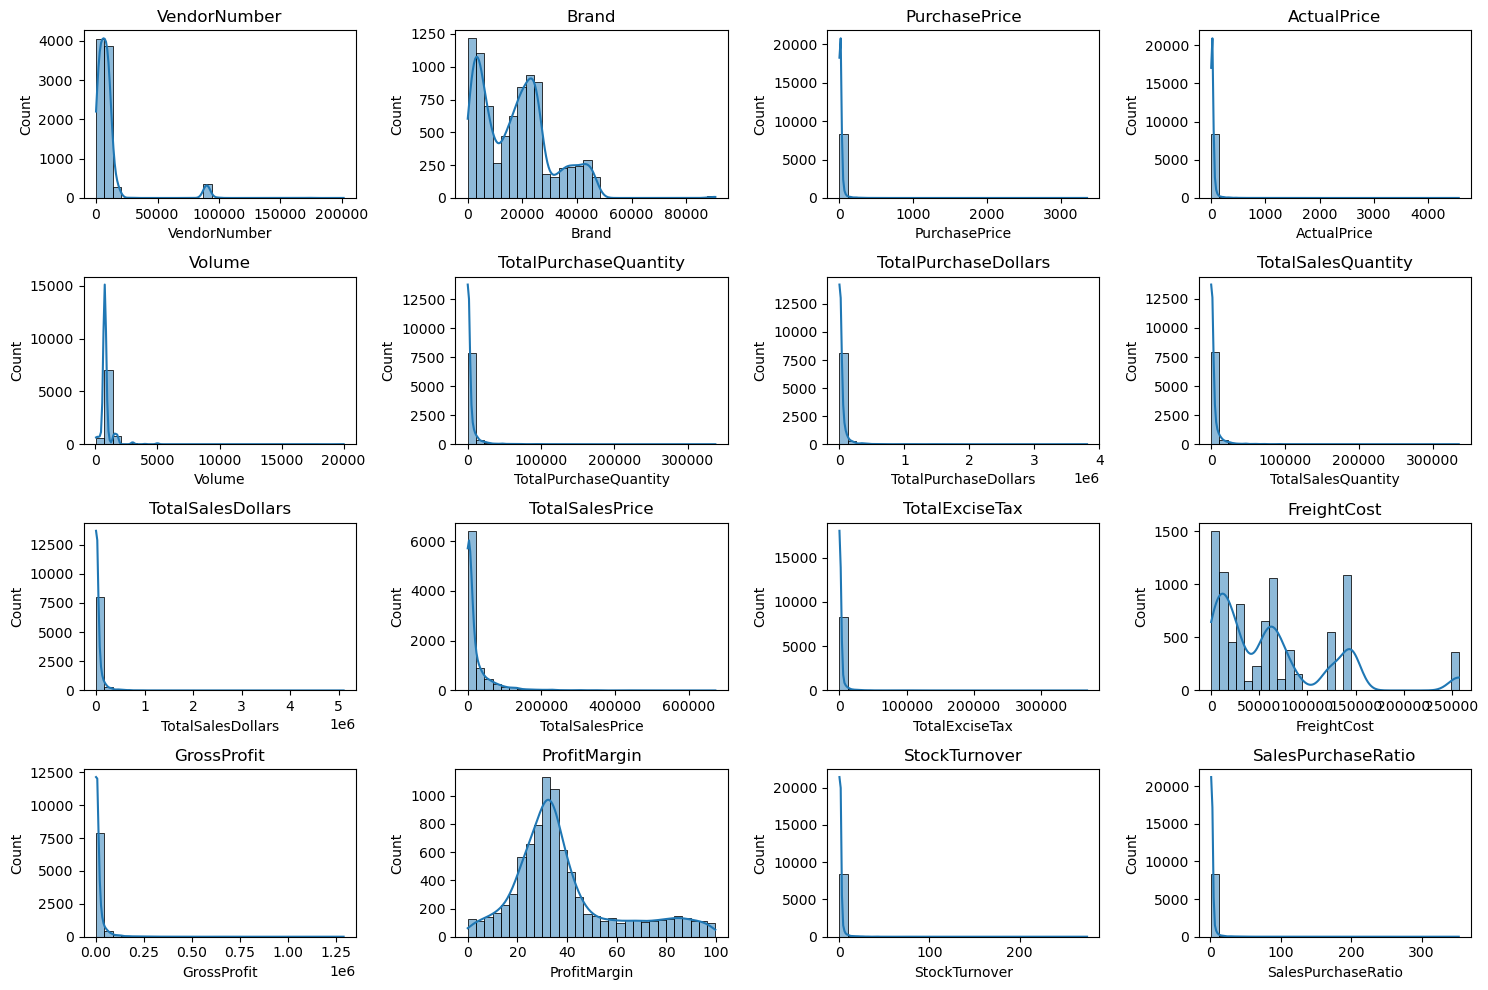

In [12]:
#Describing Plots For Numerical Columns
numerical_cols=df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)           #adjusting grid layout as needed
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

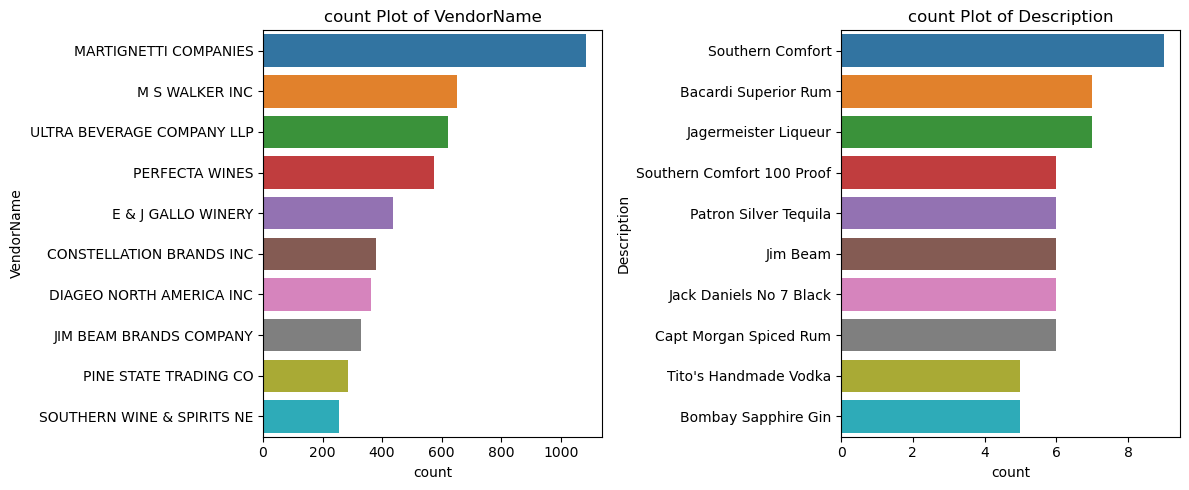

In [13]:
#count plot for cetogorical columns
categorical_cols=["VendorName","Description"]

plt.figure(figsize=(12,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10]) #top 10 categories
    plt.title(f"count Plot of {col}")
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

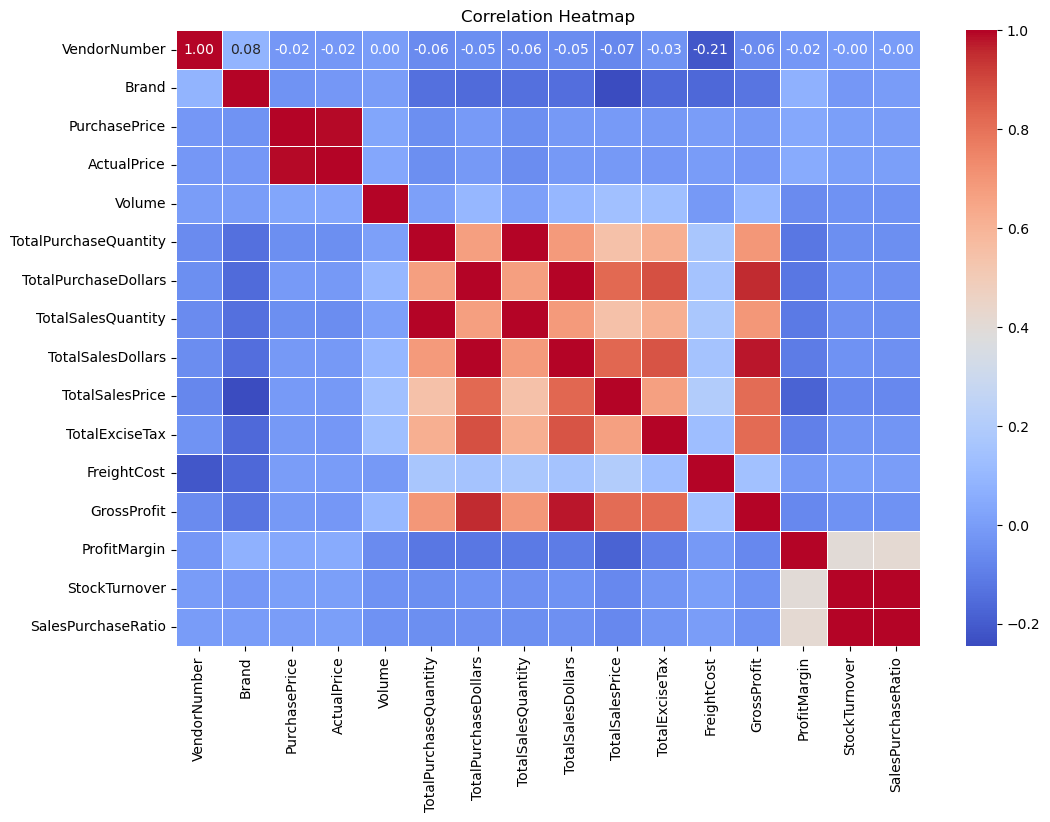

In [14]:
#correlation Heatmap
plt.figure(figsize=(12,8))
correlation_matrix=df[numerical_cols].corr()
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show

In [15]:
#correlation insights
'''================================================='''

'================================================='

# Data Analysis 
Identify Brands thst needes Promotional Or Pricing Adjustments which exhibit lower sales performance but highest profit marrgin

In [17]:
brand_performance=df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

In [18]:
brand_performance

,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,"21,519.09",18.06
1,.nparalleled Svgn Blanc,"1,094.63",29.98
2,10 Span Cab Svgn CC,"2,703.89",20.94
3,10 Span Chard CC,"3,325.56",27.81
4,10 Span Pnt Gris Monterey Cy,"2,082.22",32.23
...,...,...,...
7702,Zorvino Vyds Sangiovese,"10,579.03",29.53
7703,Zuccardi Q Malbec,"1,639.18",23.98
7704,Zum Rsl,"10,857.34",32.68
7705,Zwack Liqueur,227.88,16.65


In [19]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold=brand_performance['ProfitMargin'].quantile(0.85)

In [20]:
low_sales_threshold

560.2989873886107

In [21]:
high_margin_threshold


64.97017628692014

In [22]:
#filter brands with low sales but high profit margin 
target_brands=brand_performance[
(brand_performance['TotalSalesDollars']<=low_sales_threshold) &
(brand_performance['ProfitMargin']>=high_margin_threshold) 
]
print("Brands With Low Performance but high Margins:")
display(target_brands.sort_values('TotalSalesDollars'))


Brands With Low Performance but high Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.47
2369,Debauchery Pnt Nr,11.58,65.98
2070,Concannon Glen Ellen Wh Zin,15.95,83.45
2188,Crown Royal Apple,27.86,89.81
6237,Sauza Sprklg Wild Berry Marg,27.96,82.15
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.75
2271,Dad's Hat Rye Whiskey,538.89,81.85
57,A Bichot Clos Marechaudes,539.94,67.74
6245,Sbragia Home Ranch Merlot,549.75,66.44


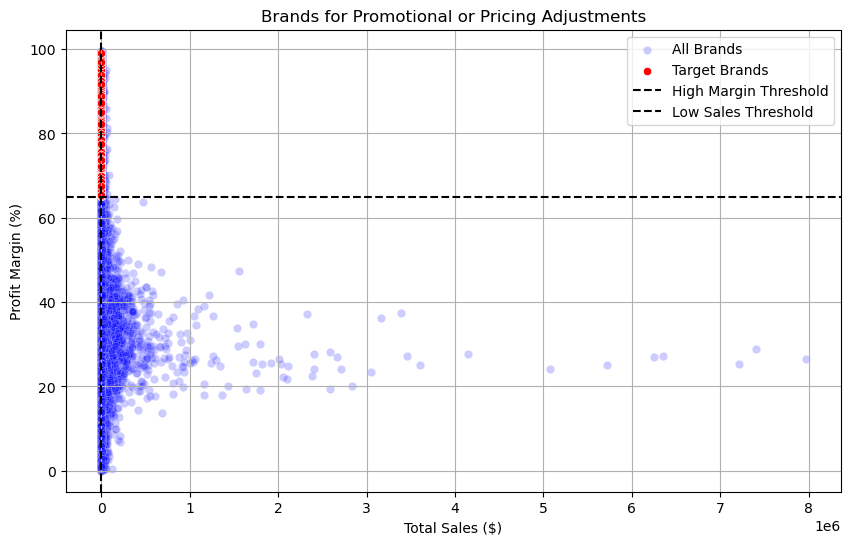

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()


In [24]:
brand_performance=brand_performance[brand_performance['TotalSalesDollars']<10000] #for better visualisation

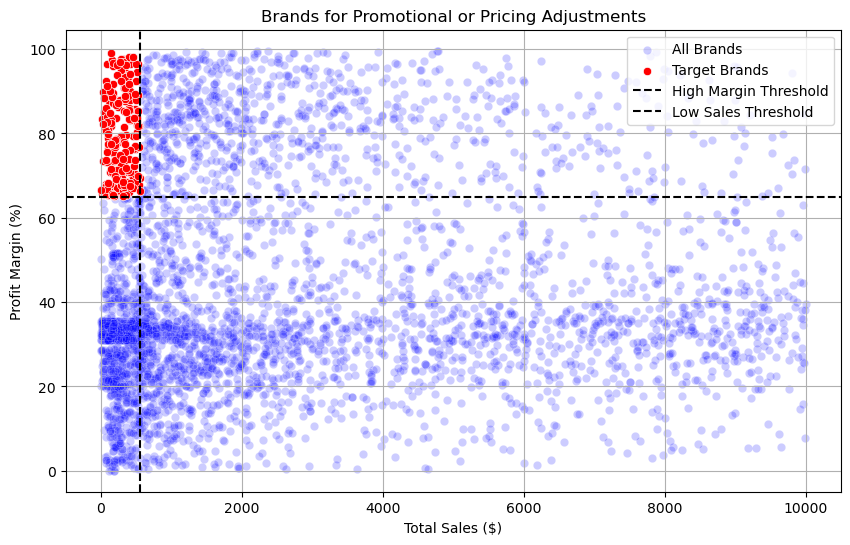

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()


Which vendors and brand demonstrate the highest sales performance ?

In [27]:
# Top Vendors & Brands by Sales Performance
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors


VendorName
DIAGEO NORTH AMERICA INC     67,990,099.43
MARTIGNETTI COMPANIES        39,330,359.27
PERNOD RICARD USA            32,063,196.15
JIM BEAM BRANDS COMPANY      31,423,020.41
BACARDI USA INC              24,854,817.11
CONSTELLATION BRANDS INC     24,218,745.45
E & J GALLO WINERY           18,399,899.29
BROWN-FORMAN CORP            18,247,230.72
ULTRA BEVERAGE COMPANY LLP   16,502,544.30
M S WALKER INC               14,706,458.43
Name: TotalSalesDollars, dtype: float64

In [28]:
def format_dollars(value):
    if value>=1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value>=1_000:
        return f"{value/1_000:.2f}K"
    else:
        return str(value)

In [29]:
top_brands


Description
Jack Daniels No 7 Black   7,964,746.79
Tito's Handmade Vodka     7,399,657.56
Grey Goose Vodka          7,209,608.08
Capt Morgan Spiced Rum    6,356,320.59
Absolut 80 Proof          6,244,752.02
Jameson Irish Whiskey     5,715,759.72
Ketel One Vodka           5,070,083.56
Baileys Irish Cream       4,150,122.08
Kahlua                    3,604,858.64
Tanqueray                 3,456,697.89
Name: TotalSalesDollars, dtype: float64

In [30]:
top_brands.apply(lambda x:format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

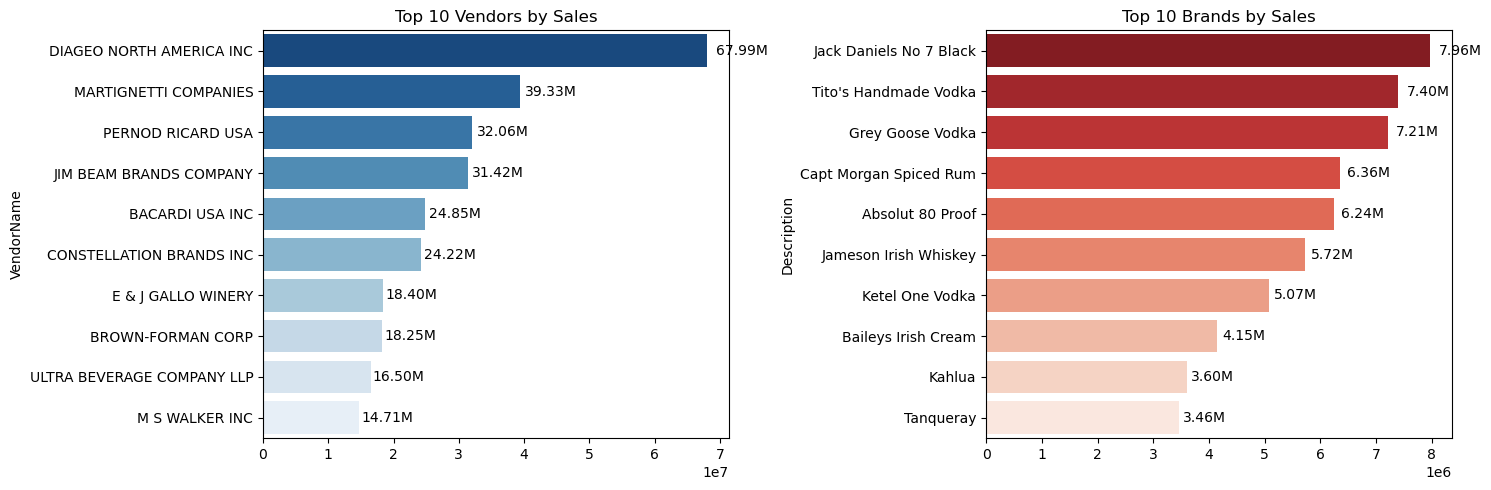

In [31]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02), 
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02), 
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


Which Vendor Contribute the most to total purchase dollars??

In [33]:
vendor_performance=df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()

In [34]:
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53
1,ALISA CARR BEVERAGES,"25,698.12","78,772.82","104,470.94"
2,ALTAMAR BRANDS LLC,"11,706.20","4,000.61","15,706.81"
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,"1,511.16"
4,AMERICAN VINTAGE BEVERAGE,"104,435.68","35,167.85","139,603.53"
...,...,...,...,...
114,WEIN BAUER INC,"42,694.64","13,522.49","56,217.13"
115,WESTERN SPIRITS BEVERAGE CO,"298,416.86","106,837.97","405,254.83"
116,WILLIAM GRANT & SONS INC,"5,876,538.25","1,693,337.99","7,569,876.24"
117,WINE GROUP INC,"5,203,801.16","3,100,242.01","8,304,043.17"


In [35]:
vendor_performance['PurchaseContribution%']=vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()

In [36]:
round(vendor_performance,2)

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53,0.00
1,ALISA CARR BEVERAGES,"25,698.12","78,772.82","104,470.94",0.00
2,ALTAMAR BRANDS LLC,"11,706.20","4,000.61","15,706.81",0.00
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,"1,511.16",0.00
4,AMERICAN VINTAGE BEVERAGE,"104,435.68","35,167.85","139,603.53",0.00
...,...,...,...,...,...
114,WEIN BAUER INC,"42,694.64","13,522.49","56,217.13",0.00
115,WESTERN SPIRITS BEVERAGE CO,"298,416.86","106,837.97","405,254.83",0.00
116,WILLIAM GRANT & SONS INC,"5,876,538.25","1,693,337.99","7,569,876.24",0.02
117,WINE GROUP INC,"5,203,801.16","3,100,242.01","8,304,043.17",0.02


In [37]:
vendor_performance.style.format({'PurchaseContribution%': '{:.4%}'})


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
0,ADAMBA IMPORTS INTL INC,446.159998,258.369991,704.529989,0.0001%
1,ALISA CARR BEVERAGES,25698.119912,78772.820175,104470.940087,0.0084%
2,ALTAMAR BRANDS LLC,11706.199825,4000.610656,15706.810481,0.0038%
3,AMERICAN SPIRITS EXCHANGE,934.080013,577.080006,1511.160019,0.0003%
4,AMERICAN VINTAGE BEVERAGE,104435.678883,35167.849724,139603.528607,0.0340%
5,ATLANTIC IMPORTING COMPANY,41116.319673,18156.429887,59272.749559,0.0134%
6,BACARDI USA INC,17432020.235303,7422796.875632,24854817.110935,5.6719%
7,BANFI PRODUCTS CORP,1608143.713758,1023941.394168,2632085.107926,0.5232%
8,BLACK PRINCE DISTILLERY INC,5854.939956,5746.259900,11601.199856,0.0019%
9,BLACK ROCK SPIRITS LLC,1152.100032,897.079966,2049.179998,0.0004%


In [38]:
vendor_performance=vendor_performance.sort_values('PurchaseContribution%',ascending=False)

In [39]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,0.16
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,0.08
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,0.08
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,0.08
6,BACARDI USA INC,17.43M,7.42M,24.85M,0.06
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,0.05
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,0.04
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,0.04
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,0.04
53,M S WALKER INC,9.76M,4.94M,14.71M,0.03


In [40]:
vendor_performance.shape

(119, 5)

In [41]:
top_vendors['PurchaseContribution%'].sum()

0.6568955597461941

In [42]:
top_vendors['Cumulative_Contribution%']=top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,0.16,0.16
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,0.08,0.25
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,0.08,0.32
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,0.08,0.40
6,BACARDI USA INC,17.43M,7.42M,24.85M,0.06,0.46
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,0.05,0.51
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,0.04,0.55
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,0.04,0.59
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,0.04,0.63
53,M S WALKER INC,9.76M,4.94M,14.71M,0.03,0.66


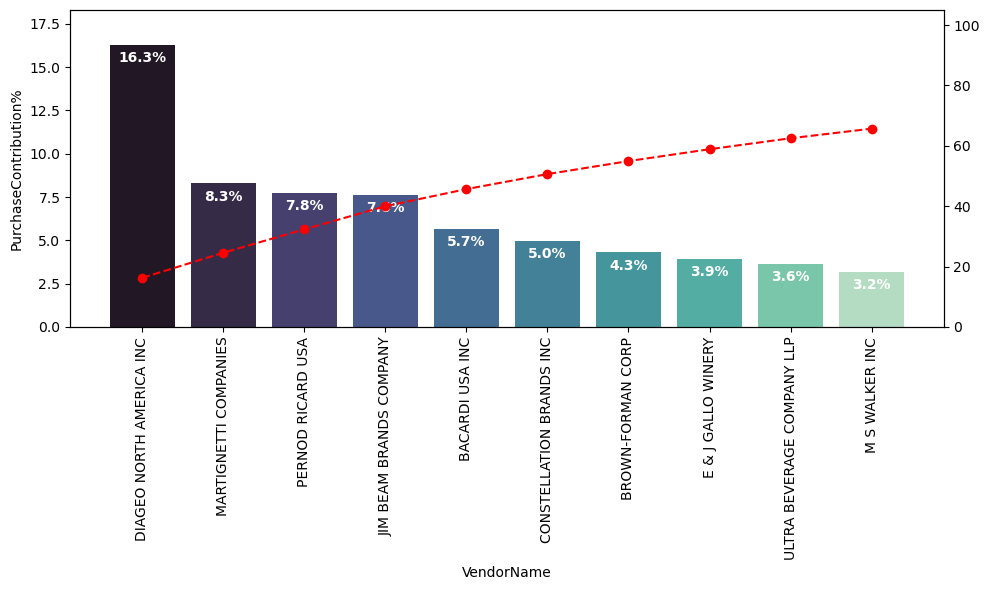

In [43]:
# Fix the data scales
top_vendors['PurchaseContribution%'] = top_vendors['PurchaseContribution%'] * 100
top_vendors['Cumulative_Contribution%'] = top_vendors['Cumulative_Contribution%'] * 100

# Now run the plot code
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)

# Add text labels (now they will show as 16.3 instead of 0.16)
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, f'{value:.1f}%', ha='center', fontsize=10, color='white', fontweight='bold')

# Line Plot (this will now climb toward 100 on the right axis)
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative %')

# Set limits to ensure the scales match the visual
ax1.set_ylim(0, top_vendors['PurchaseContribution%'].max() + 2)
ax2.set_ylim(0, 105)

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
plt.tight_layout()
plt.show()


How much of the total procurement is dependent on the top vendors?

In [45]:
print(f"Total Purchase Contribution Of the Top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)}%")

Total Purchase Contribution Of the Top 10 vendors is 65.69%


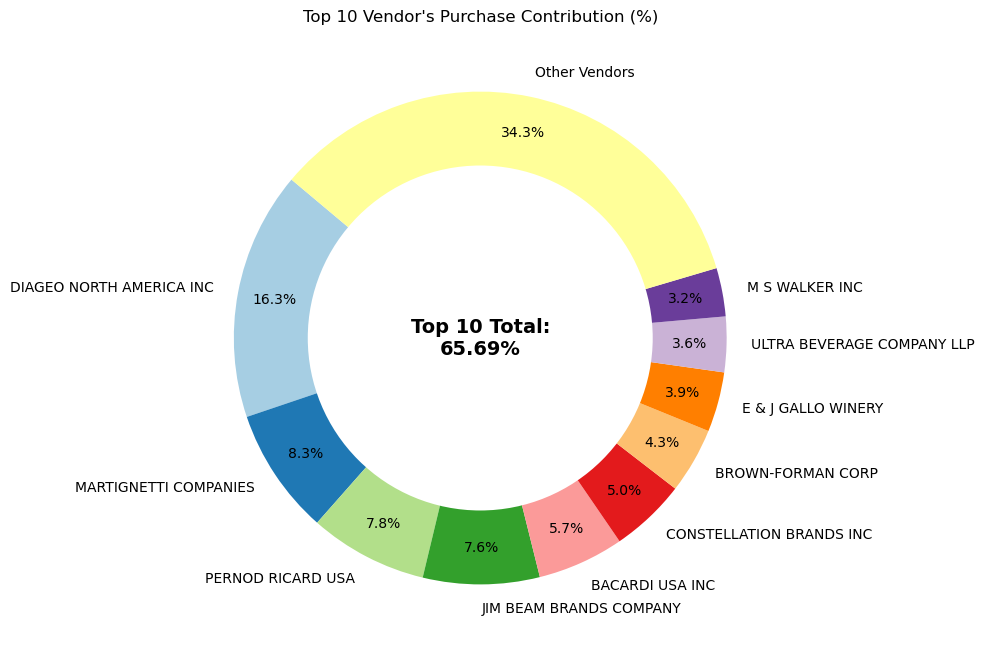

In [46]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
                                  startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()


Does Purchasing in bulk reduce the unit price and what is the optimal purchasae volume for cost saving 

In [48]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio,UnitPurchasePrice
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,"1,750.00",145080,"3,811,251.60","142,049.00","5,101,919.55","672,819.34","260,999.20","68,601.68","1,290,667.95",25.30,0.98,1.34,26.27
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,"1,750.00",164038,"3,804,041.22","160,247.00","4,819,073.49","561,512.38","294,438.66","144,929.24","1,015,032.27",21.06,0.98,1.27,23.19
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,"1,750.00",187407,"3,418,303.68","187,140.00","4,538,120.59","461,140.15","343,854.07","123,780.22","1,119,816.91",24.68,1.00,1.33,18.24
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,"1,750.00",201682,"3,261,197.94","200,412.00","4,475,972.86","420,050.01","368,242.80","257,032.07","1,214,774.91",27.14,0.99,1.37,16.17
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,"1,750.00",138109,"3,023,206.00","135,838.00","4,223,107.62","545,778.28","249,587.83","257,032.07","1,199,901.62",28.41,0.98,1.40,21.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.00,2,2.64,5.00,15.95,10.96,0.55,"27,100.41",13.31,83.45,2.50,6.04,1.32
8561,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.00,6,2.34,134.00,65.66,1.47,7.04,"50,293.62",63.32,96.44,22.33,28.06,0.39
8562,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.00,2,1.48,2.00,1.98,0.99,0.10,"14,069.87",0.50,25.25,1.00,1.34,0.74
8563,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.00,1,1.47,72.00,143.28,77.61,15.12,"257,032.07",141.81,98.97,72.00,97.47,1.47


In [49]:
df["OrderSize"]=pd.qcut(df["TotalPurchaseQuantity"],q=3,labels=["Small","Medium","Large"])

In [50]:
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Large,145080
1,Large,164038
2,Large,187407
3,Large,201682
4,Large,138109
...,...,...
8560,Small,2
8561,Small,6
8562,Small,2
8563,Small,1


In [51]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.06
Medium,15.49
Large,10.78


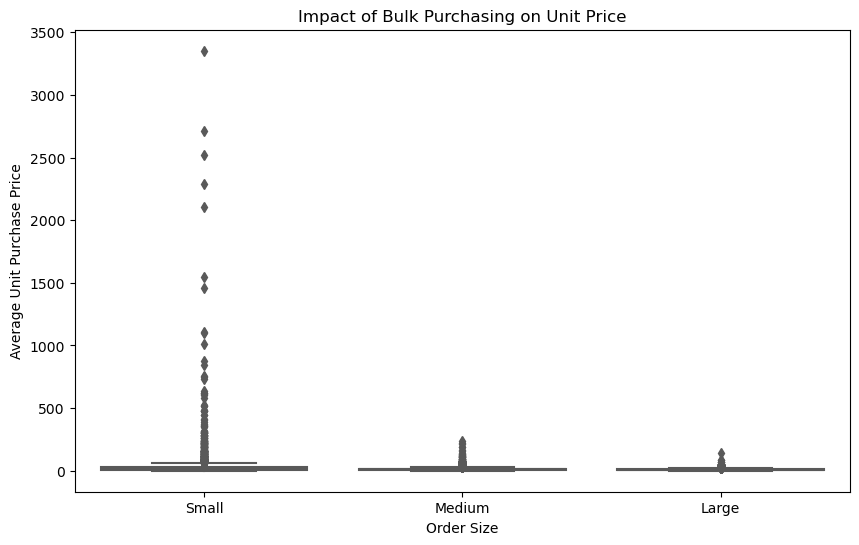

In [52]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()


In [53]:
'''+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++'''

'+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++'

Which vendor have low inventory turnover,indicating excess stock and slow-moving products?

In [55]:
df[df['StockTurnover']<1]

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio,UnitPurchasePrice,OrderSize
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,"1,750.00",145080,"3,811,251.60","142,049.00","5,101,919.55","672,819.34","260,999.20","68,601.68","1,290,667.95",25.30,0.98,1.34,26.27,Large
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,"1,750.00",164038,"3,804,041.22","160,247.00","4,819,073.49","561,512.38","294,438.66","144,929.24","1,015,032.27",21.06,0.98,1.27,23.19,Large
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,"1,750.00",187407,"3,418,303.68","187,140.00","4,538,120.59","461,140.15","343,854.07","123,780.22","1,119,816.91",24.68,1.00,1.33,18.24,Large
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,"1,750.00",201682,"3,261,197.94","200,412.00","4,475,972.86","420,050.01","368,242.80","257,032.07","1,214,774.91",27.14,0.99,1.37,16.17,Large
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,"1,750.00",138109,"3,023,206.00","135,838.00","4,223,107.62","545,778.28","249,587.83","257,032.07","1,199,901.62",28.41,0.98,1.40,21.89,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8192,653,STATE WINE & SPIRITS,24371,Tozai Typhoon Sake,10.45,15.99,720.00,6,62.70,5.00,79.95,79.95,0.55,"8,014.98",17.25,21.58,0.83,1.28,10.45,Small
8202,9552,M S WALKER INC,398,S S Pierce Ninety Nine Gin,5.63,7.49,"1,000.00",11,61.93,9.00,67.41,7.49,9.45,"55,551.82",5.48,8.13,0.82,1.09,5.63,Small
8203,1392,CONSTELLATION BRANDS INC,16916,R Mondavi Malbec Private Slt,5.15,7.99,750.00,12,61.80,10.00,85.90,34.96,1.12,"79,528.99",24.10,28.06,0.83,1.39,5.15,Small
8243,8352,LUXCO INC,8629,Ezra Brooks Cinnamon Bourbon,11.02,13.99,"1,750.00",5,55.10,3.00,56.97,37.98,5.51,"10,261.60",1.87,3.28,0.60,1.03,11.02,Small


In [56]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean()

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.62
ALTAMAR BRANDS LLC,0.96
AMERICAN SPIRITS EXCHANGE,0.88
AMERICAN VINTAGE BEVERAGE,0.96
ATLANTIC IMPORTING COMPANY,0.89
...,...
WEIN BAUER INC,0.85
WESTERN SPIRITS BEVERAGE CO,0.90
WILLIAM GRANT & SONS INC,0.91


In [57]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.62
HIGHLAND WINE MERCHANTS LLC,0.71
PARK STREET IMPORTS LLC,0.75
Circa Wines,0.76
Dunn Wine Brokers,0.77
CENTEUR IMPORTS LLC,0.77
SMOKY QUARTZ DISTILLERY LLC,0.78
TAMWORTH DISTILLING,0.80
THE IMPORTED GRAPE LLC,0.81


How much capital is locked in unsold inventory per vendor contribution the most to it?

In [59]:
df["UnsoldInventoryValue"]=(df["TotalPurchaseQuantity"]-df["TotalSalesQuantity"])*df["PurchasePrice"]
print('Total Unsold Capital:',format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 2.71M


In [60]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)


,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


what is the 95% confidence intervals fro profit margin of top-performing and low performing vendors

In [62]:
top_threshold=df["TotalSalesDollars"].quantile(0.75)
low_threshold=df["TotalSalesDollars"].quantile(0.25)

In [63]:
top_vendors=df[df["TotalSalesDollars"]>=top_threshold]["ProfitMargin"].dropna()
low_vendors=df[df["TotalSalesDollars"]<=low_threshold]["ProfitMargin"].dropna()

In [64]:
top_vendors

0      25.30
1      21.06
2      24.68
3      27.14
4      28.41
        ... 
3523   79.68
3681   85.78
4751   93.09
4920   95.01
5050   94.27
Name: ProfitMargin, Length: 2142, dtype: float64

In [65]:
low_vendors

5631    4.11
5652    6.15
5701   12.01
5704    1.68
5724    7.24
        ... 
8560   83.45
8561   96.44
8562   25.25
8563   98.97
8564   99.17
Name: ProfitMargin, Length: 2142, dtype: float64

In [66]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error


Top Vendors 95% CI: (30.74, 31.61), Mean: 31.17
Low Vendors 95% CI: (40.48, 42.62), Mean: 41.55


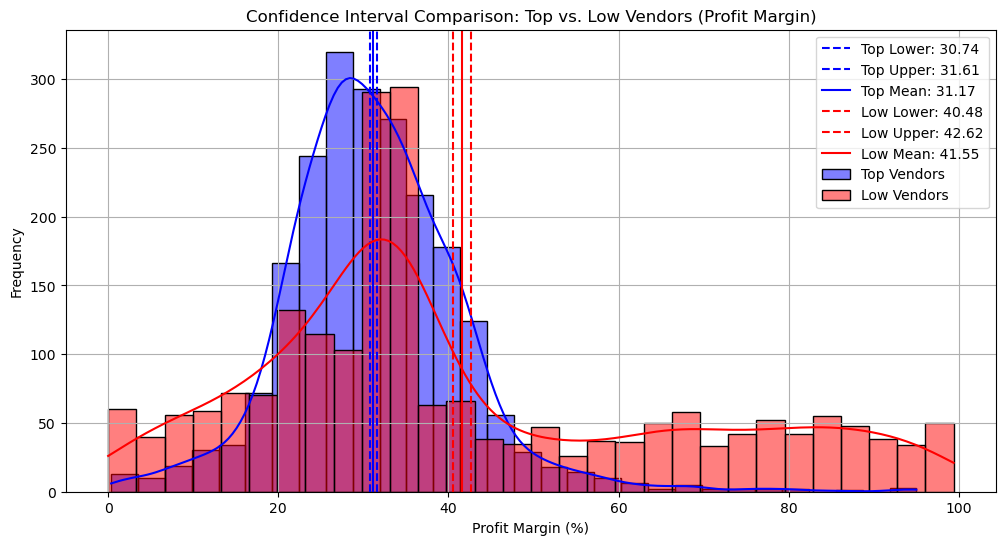

In [67]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


In [68]:
'''================================================================================'''

'================================================================================'

# Is there a significant diffrence in profit margins between top-performing and low-performing vendors?
Hypothesis:
- He(Null Hypothesis):There is no significant diffrence in the mean profit margins of top performing and low performing vendors.
- H1(Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly diffrent 

In [70]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")


T-Statistic: -17.6440, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.


In [71]:
print("done")

done


In [73]:

print(vendor_sales_summary.columns.tolist())
print(BrandPerformance.columns.tolist())


NameError: name 'vendor_sales_summary' is not defined

In [ ]:
'''import os
os.makedirs('PowerBI_Data', exist_ok=True)

BrandPerformance.to_csv('PowerBI_Data/brandperformance.csv', index=False)

print("All files exported.")'''

In [ ]:
'''import os

# 1. Create a folder to store your CSVs if it doesn't exist
os.makedirs('PowerBI_Data', exist_ok=True)

# 2. Export Brand Performance (You already have this, but let's keep it together)
BrandPerformance.to_csv('PowerBI_Data/BrandPerformance.csv', index=False)

# 3. Export Purchase Contribution 
# Using the 'vendor_performance' dataframe you created in cell 37
vendor_performance.to_csv('PowerBI_Data/PurchaseContribution.csv', index=False)

# 4. Export Low Turnover Vendors
# Taking the logic you used in cell 62 and saving it to a variable first
low_turnover_vendors = df[df['StockTurnover'] < 1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending=True)

# We reset the index so 'VendorName' becomes a column in the CSV rather than the index
low_turnover_vendors.reset_index().to_csv('PowerBI_Data/LowTurnoverVendor.csv', index=False)

print("Success! BrandPerformance.csv, PurchaseContribution.csv, and LowTurnoverVendor.csv have been saved in the 'PowerBI_Data' folder.")'''

In [ ]:
import os

# 1. Create a folder to store your CSVs if it doesn't exist
os.makedirs('PowerBI_Data', exist_ok=True)

# 2. Export Brand Performance (Fixed the lowercase 'b' and 'p')
brand_performance.to_csv('PowerBI_Data/BrandPerformance.csv', index=False)

# 3. Export Purchase Contribution 
# Using the 'vendor_performance' dataframe you created earlier
vendor_performance.to_csv('PowerBI_Data/PurchaseContribution.csv', index=False)

# 4. Export Low Turnover Vendors
low_turnover_vendors = df[df['StockTurnover'] < 1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending=True)

# Reset index so 'VendorName' becomes a column in the CSV rather than the index
low_turnover_vendors.reset_index().to_csv('PowerBI_Data/LowTurnoverVendor.csv', index=False)

print("Success! BrandPerformance.csv, PurchaseContribution.csv, and LowTurnoverVendor.csv have been saved in the 'PowerBI_Data' folder.")

In [75]:
import os
os.makedirs('PowerBI_Data', exist_ok=True)
Vendor_sales_summary.to_csv('PowerBI_Data/Vendor_sales_summary.csv', index=False)
print("Success! BrandPerformance.csv, PurchaseContribution.csv, and LowTurnoverVendor.csv have been saved in the 'PowerBI_Data' folder.")

NameError: name 'Vendor_sales_summary' is not defined